#**Packages**

In [2]:
import numpy as np
import matplotlib.pyplot as plt

#**Mesh Generation**

In [3]:
def create_mesh(a, b, n, flag):
    # creates 3 different types of meshes (uniform, Chebyshev 1, Chebyshev 2)

    # Parameters:
        # a: lower bound of the interval
        # b: upper bound of the interval
        # n: number of points
        # flag: flag indicating which kind of mesh to create (1 for uniform, 2 for Chebyshev 1st kind, 3 for Chebyshev 2nd kind)

    # Returns:
        # x_mesh: mesh of points of the desired type

    x_mesh = np.zeros(n+1)   # initializes storage

    if flag == 1: # creates a uniform mesh
        x_mesh = np.linspace(a, b, n+1)

    elif flag == 2:   # creates Chebyshev points of the 1st kind
        for i in range(n+1):
            x_mesh[i] = 0.5*(b-a) * np.cos(((2*i + 1) * np.pi) / (2 * n + 2)) + 0.5*(b+a)

    elif flag == 3:   # creates Chebyshev points of the 2nd kind
        for i in range(n+1):
            x_mesh[i] = 0.5*(b-a) * np.cos((i * np.pi)/ n) + 0.5*(b+a)

    return x_mesh



#**Interpolating Polynomial**

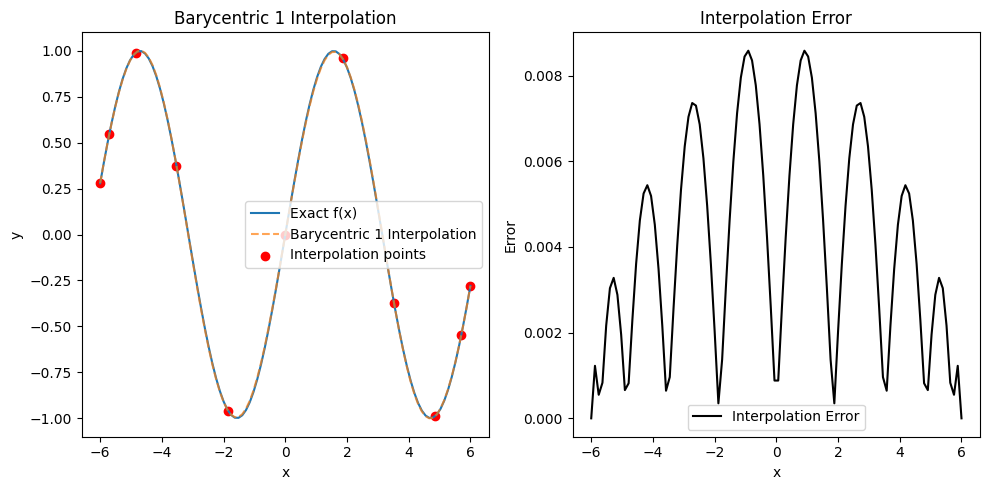

In [117]:
def bary_1_gammas(x_mesh, f):
    # Computes the gamma coefficients in the Barycentric 1 formula
    # Computes the function values at the mesh points

    n = len(x_mesh) - 1  # The mesh has n+1 points
    x_mesh = np.array(x_mesh)

    gamma_weights = np.zeros(n + 1)   # Initializes storage

    # Compute gamma weights
    for i in range(n + 1):
        omega_prime = 1
        for j in range(n + 1):  # Computes the omega primes (skips j=i case)
            if j != i:
                omega_prime *= (x_mesh[i] - x_mesh[j])
        gamma_weights[i] = 1 / omega_prime   # Computes inverse for gammas

    # Compute function values
    function_values = np.array(f(x_mesh))  # Pass entire x_mesh at once

    return gamma_weights, function_values


def bary_1_interpolation(x_mesh, y_mesh, x_points, gamma_weights):
    # Evaluates Barycentric Form 1 interpolation

    x_mesh = np.array(x_mesh)
    y_mesh = np.array(y_mesh)
    x_points = np.array(x_points)
    gamma_weights = np.array(gamma_weights)

    n = len(x_mesh) - 1  # Degree n polynomial for n+1 points
    eval_len = len(x_points)
    interp_eval = np.zeros(eval_len)  # Initializing result array

    for j in range(eval_len):  # Looping over points to be interpolated
        numerically_close = np.isclose(x_points[j], x_mesh, atol=1e-10).any()

        if numerically_close:  # If an interpolated point is close to a mesh point, use the exact y value
            interp_eval[j] = y_mesh[np.argmin(np.abs(x_points[j] - x_mesh))]
            continue

        omega = 1
        for i in range(n + 1):
            omega *= (x_points[j] - x_mesh[i])  # Computing omega_{n+1}(x)

        term = 0
        for i in range(n + 1):  # Computing the weighted sum using gamma_weights
            term += ((y_mesh[i] * gamma_weights[i]) / (x_points[j] - x_mesh[i]))

        interp_eval[j] = omega * term  # Computing p_n(x)


    return interp_eval


def f(x):
    #return 4*x**3 + 3*x**2 + 2*x + 1
    return np.sin(x)

# Interpolation mesh
x_mesh = create_mesh(-6, 6, 10, 3)
y_mesh = f(x_mesh)

# Compute barycentric 1 weights
gamma_weights, function_values = bary_1_gammas(x_mesh, f)

# Evaluate interpolant
x_points = np.linspace(-6, 6, 100)
y_exact = f(x_points)
y_interp = bary_1_interpolation(x_mesh, y_mesh, x_points, gamma_weights)

# Plot results
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(x_points, y_exact, label="Exact f(x)")
plt.plot(x_points, y_interp, '--', label="Barycentric 1 Interpolation", alpha=0.7)
plt.scatter(x_mesh, y_mesh, color="red", label="Interpolation points")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Barycentric 1 Interpolation")

plt.subplot(1, 2, 2)
error = np.abs(y_exact - y_interp)
plt.plot(x_points, error, 'k', label="Interpolation Error")
#plt.yscale('log')
plt.legend()
plt.xlabel("x")
plt.ylabel("Error")
plt.title("Interpolation Error")

plt.tight_layout()
plt.show()



#**Divided Differences**

In [5]:
def divided_differences(x_mesh, f):
    # Computes function values at given mesh points
    # Computes divided differences and stores them in a 1D array (O(n) space complexity)

    # Parameters:
        # x_mesh: mesh points
        # f: function to be interpolated

    # Returns:
        # div_diff_list: 1D array of divided differences
        # function_values: the function values to be used in the interpolation

    n = len(x_mesh)

    function_values = np.zeros(n)  # Initialize in specified precision
    function_values = np.array(f(x_mesh))  # Pass entire x_mesh at once

    coeffs = np.copy(function_values)  # Initialize coefficients array

    for i in range(1, n):  # Compute divided differences iteratively
        for j in range(n-1, i-1, -1):
            coeffs[j] = (coeffs[j] - coeffs[j-1]) / (x_mesh[j] - x_mesh[j-i])

    return coeffs, function_values



#**Piecewise Interpolating Polynomial**

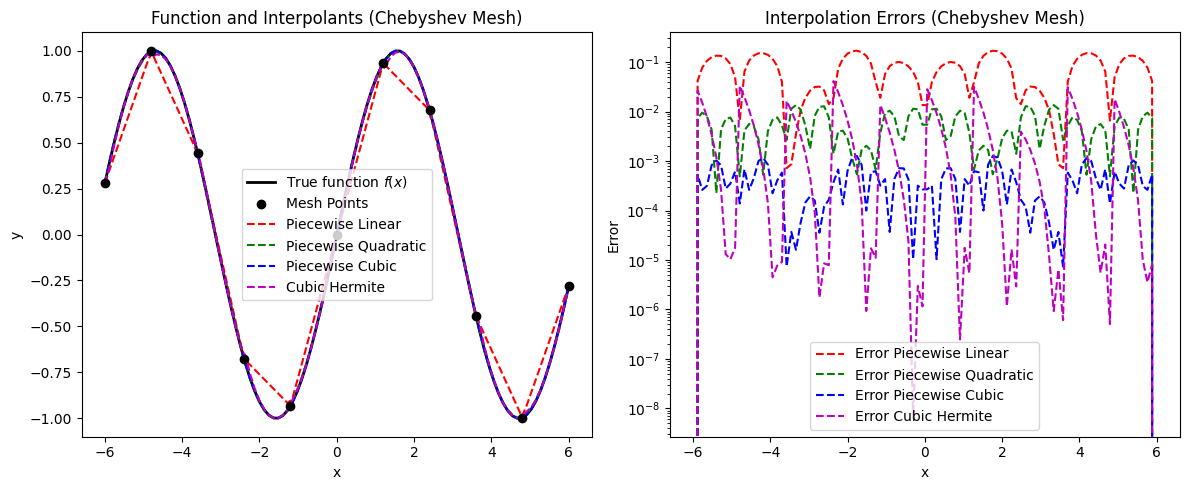

In [124]:
def piecewise_interpolating_polynomial(f, f_prime, a, b, n_intervals, degree, method="uniform", hermite=False):
    # Constructs a piecewise interpolating polynomial g_d(x) on [a, b]
    # Parameters:
        # f: function to interpolate
        # f_prime: derivative function (needed if hermite=True)
        # a, b: endpoints of the interval
        # n_intervals: number of subintervals
        # degree: degree of the polynomial (1, 2, or 3)
        # method: "uniform" or "chebyshev" for node selection
        # hermite: whether to use cubic Hermite interpolation
    # Returns:
        # gd: Function that evaluates the piecewise interpolating polynomial at x

    nodes = np.linspace(a, b, n_intervals + 1)  # Subinterval endpoints
    local_polynomials = []  # Store polynomial coefficients and points

    for i in range(n_intervals):
        ai, bi = nodes[i], nodes[i+1]

        # Select interpolation points
        if method == "uniform":
            x_points = np.linspace(ai, bi, degree + 1)
        elif method == "chebyshev":
            x_points = create_mesh(ai, bi, degree, flag=3)  # Chebyshev 2nd kind

        if hermite:
            y_values = np.array([f(x) for x in x_points])
            dy_values = np.array([f_prime(x) for x in x_points])
            coeffs = hermite_divided_differences(x_points, y_values, dy_values)
        else:
            coeffs, _ = divided_differences(x_points, f)

        local_polynomials.append((x_points, coeffs))

    def gd(x):
        tol = 1e-10  # Small tolerance for floating-point comparisons

        # Check if x is exactly a mesh point
        for node in nodes:
            if abs(x - node) < tol:  # If x is a node, return f(x) immediately
                return f(node)

        # If x is not a mesh point, proceed with interpolation
        for i in range(n_intervals):
            ai, bi = nodes[i], nodes[i+1]
            if ai <= x <= bi:
                x_points, coeffs = local_polynomials[i]
                if hermite:
                    return evaluate_newton_polynomial_hermite(x, x_points, coeffs)
                else:
                    return evaluate_newton_polynomial(x, x_points, coeffs)

        return None  # Outside range


    return gd, nodes

def evaluate_newton_polynomial(x, x_points, coeffs):
    # Evaluates Newton's interpolating polynomial at x
    n = len(x_points)
    result = coeffs[-1]
    for i in range(n - 2, -1, -1):
        result = result * (x - x_points[i]) + coeffs[i]
    return result

def evaluate_newton_polynomial_hermite(x, x_points, coeffs):
    # Evaluates Newton's interpolating polynomial at x when using Hermite
    result = coeffs[0] + (coeffs[1] * (x - x_points[0])) + (coeffs[2] * ((x - x_points[0])**2)) + (coeffs[3] * ((x - x_points[0])**2) * (x - x_points[1]))
    return result

def hermite_divided_differences(x, y, dy):
    # Computes the 4 coefficients when using Hermite
    coeffs = np.zeros(4)   # 4 coefficients for a cubic polynomial
    hi = x[1] - x[0]

    coeffs[0] = y[0]
    coeffs[1] = dy[0]
    coeffs[2] = ((y[1] - y[0]) / (hi**2)) - (dy[0] / hi)
    coeffs[3] = ((dy[1] + dy[0]) / (hi**2)) - ((2*(y[1] - y[0])) / (hi**3))

    return coeffs


def plot_interpolation(f, gd_list, labels, nodes, a, b, n_points=100):
    x_fine = np.linspace(a, b, n_points)  # Fine mesh for plotting
    y_true = f(x_fine)  # True function values

    plt.figure(figsize=(12, 5))

    # Plot the function and interpolants
    plt.subplot(1, 2, 1)
    plt.plot(x_fine, y_true, 'k-', linewidth=2, label="True function $f(x)$")
    plt.scatter(nodes, f(nodes), color='black', zorder=3, label="Mesh Points")

    linestyles = ['r--', 'g--', 'b--', 'm--']
    errors = []

    for i, (gd, label) in enumerate(zip(gd_list, labels)):
        y_interp = np.array([gd(x) for x in x_fine])
        plt.plot(x_fine, y_interp, linestyles[i], label=label)
        errors.append(np.abs(y_true - y_interp))

    plt.legend()
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Function and Interpolants (Chebyshev Mesh)")

    # Plot the errors
    plt.subplot(1, 2, 2)
    for i, (error, label) in enumerate(zip(errors, labels)):
        plt.plot(x_fine, error, linestyles[i], label=f"Error {label}")

    plt.xlabel("x")
    plt.ylabel("Error")
    plt.yscale('log')
    plt.title("Interpolation Errors (Chebyshev Mesh)")
    plt.legend()

    plt.tight_layout()
    plt.show()



# TESTS
f = lambda x: np.sin(x)
f_prime = lambda x: np.cos(x)

a, b = -6, 6  # Interval
n_intervals = 10  # Number of subintervals
degree_list = [1, 2, 3]  # Different interpolation degrees
labels = ["Piecewise Linear", "Piecewise Quadratic", "Piecewise Cubic", "Cubic Hermite"]

gd_list = []
for degree in degree_list:
    gd, nodes = piecewise_interpolating_polynomial(f, None, a, b, n_intervals, degree, method="chebyshev", hermite=False)
    gd_list.append(gd)

gd_hermite, _ = piecewise_interpolating_polynomial(f, f_prime, a, b, n_intervals, 3, method="chebyshev", hermite=True)
gd_list.append(gd_hermite)

# Plot the function, interpolants, and errors
plot_interpolation(f, gd_list, labels, nodes, a, b)



#**Spline Code 1 (s''_i parameterization)**


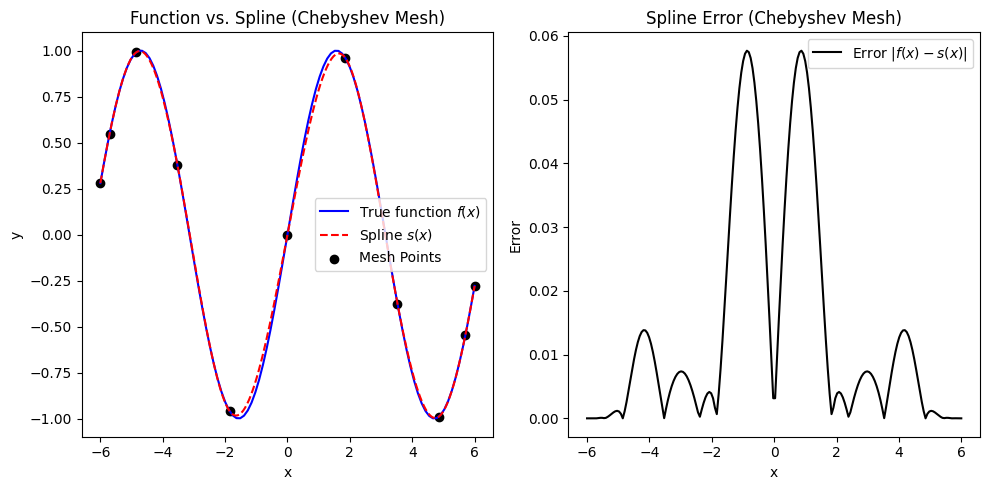

In [127]:
def f(x):
    x = np.array(x)
    #return 4*np.power(x,3) + 3*np.power(x,2) + 2*x + 1
    return np.sin(x)
def f_dprime(x):
    #return 24*x + 6
    return -1*np.sin(x)

def tridiagonal_system(main_diag, sub_diag, super_diag, b):
    # Solves a tridiagonal system Ax = b where the main diagonal has a constant value
    # Parameters:
        # main_diag: constant value of the main diagonal
        # sub_diag: sub-diagonal elements array
        # super_diag: super-diagonal elements arry
        # b: right-hand side vector
    # Returns:
        # x: solution vector

    n = len(b)
    x = np.zeros(n)

    alpha = np.zeros(n-1)
    beta = np.zeros(n)

    alpha[0] = super_diag[0] / main_diag
    beta[0] = b[0] / main_diag

    for i in range(1, n-1):
        divisor = main_diag - sub_diag[i-1] * alpha[i-1]
        alpha[i] = super_diag[i] / divisor
        beta[i] = (b[i] - sub_diag[i-1] * beta[i-1]) / divisor

    beta[-1] = (b[-1] - sub_diag[n-2] * beta[n-2]) / (main_diag - sub_diag[n-2] * alpha[n-2])

    x[-1] = beta[-1]
    for i in range(n-2, -1, -1):
        x[i] = beta[i] - alpha[i] * x[i+1]

    return x


def evaluate_spline(x_mesh, x_vals, gamma_vec, gamma_tilde_vec, s_dprime_vec, h_vec):
    # using s double prime parameterization
    interp = []
    n_intervals = len(x_mesh) - 1

    for x in x_vals:
        for i in range(n_intervals):
            a_i, b_i = x_mesh[i], x_mesh[i+1]
            if a_i <= x <= b_i:
                interpolated_value = (
                    (s_dprime_vec[i] * (b_i - x)**3) / (6 * h_vec[i+1]) + (s_dprime_vec[i+1] * (x - a_i)**3) / (6 * h_vec[i+1]) + gamma_vec[i] * (x - a_i) + gamma_tilde_vec[i])
                interp.append(interpolated_value)
                break  # exit the loop once a match is found to avoid redundancy
    return interp


a = -6   # set interval endpoints
b = 6
n = 10   # number of intervals

s_dprime_0 = f_dprime(a)   # compute boundary conditions
s_dprime_n = f_dprime(b)

x_fine = np.linspace(a, b, 100)  # Fine mesh for plotting
y_true = f(x_fine)  # True function values

#x_mesh = np.linspace(a, b, n + 1)   # Uniform
x_mesh = create_mesh(a, b, n, 3)   # Chebyshev
x_mesh = sorted(x_mesh)

f_mesh = f(x_mesh)
h_vec = np.diff(x_mesh)   # compute step sizes
h_vec = np.insert(h_vec, 0, np.nan)   # maintain alignment

h_sum = h_vec[1:-1] + h_vec[2:]   # compute h_i + h_{i+1}
mu_vec = h_vec[1:-1] / h_sum   # compute subdiagonal
lambda_vec = h_vec[2:] / h_sum   # compute superdiagonal

df_right = (f_mesh[2:] - f_mesh[1:-1]) / h_vec[2:]  # right divided difference
df_left = (f_mesh[1:-1] - f_mesh[:-2]) / h_vec[1:-1]  # left divided difference
d_vec = (6 / h_sum) * (df_right - df_left)   # compute right hand side vector

d_vec[0] -= mu_vec[0] * s_dprime_0
d_vec[-1] -= lambda_vec[-1] * s_dprime_n

s_dprime_vec = tridiagonal_system(2, mu_vec[1:], lambda_vec[:-1], d_vec)   # solve tridiagonal system
s_dprime_vec = np.insert(s_dprime_vec, 0, s_dprime_0)   # add back in boundary conditions
s_dprime_vec = np.append(s_dprime_vec, s_dprime_n)

gamma_tilde_vec = f_mesh[:-1] - (s_dprime_vec[:-1] * h_vec[1:] ** 2) / 6   # compute last two parameters
gamma_vec = (f_mesh[1:] - f_mesh[:-1]) / h_vec[1:] - (h_vec[1:] / 6) * (s_dprime_vec[1:] - s_dprime_vec[:-1])

# Evaluate spline
x_test = np.linspace(a, b, 200)
interp = evaluate_spline(x_mesh, x_test, gamma_vec, gamma_tilde_vec, s_dprime_vec, h_vec)


# Evaluate error
error = np.abs(f(x_test)-interp)

# Plot the function, interpolant, and error
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(x_fine, y_true, 'b-', label="True function $f(x)$")
plt.plot(x_test, interp, 'r--', label="Spline $s(x)$")
plt.scatter(x_mesh, f_mesh, color='black', label="Mesh Points")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Function vs. Spline (Chebyshev Mesh)")

plt.subplot(1, 2, 2)
plt.plot(x_test, error, 'k-', label="Error $|f(x) - s(x)|$")
plt.xlabel("x")
plt.ylabel("Error")
plt.title("Spline Error (Chebyshev Mesh)")
plt.legend()

plt.tight_layout()
plt.show()




#**Spline Code 2 (B Spline)**

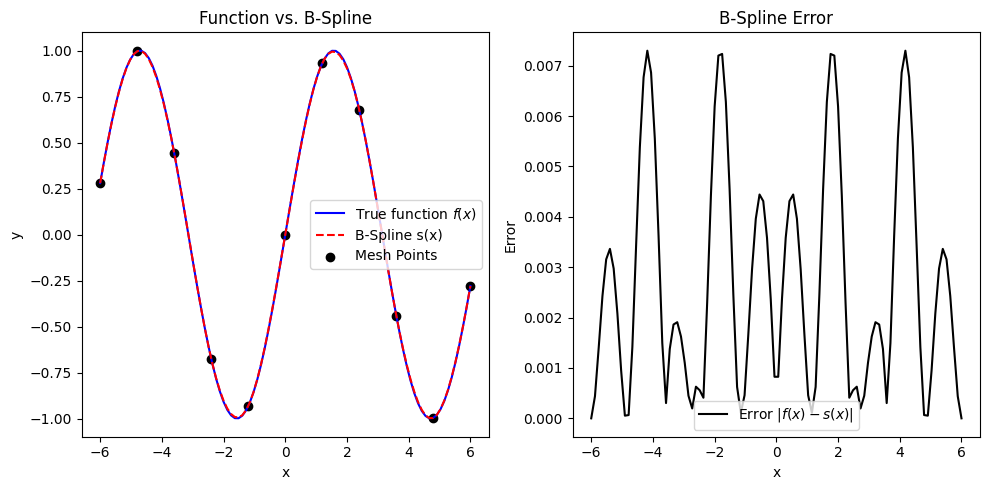

In [122]:
def f(x):
    #return 4*x**3 + 3*x**2 + 2*x + 1
    return np.sin(x)

def f_prime(x):
    #return 12*x**2 + 6*x + 2
    return np.cos(x)

def f_double_prime(x):
    #return 24*x + 6
    return -1*np.sin(x)


def evaluate_B_spline(x_mesh, x_vals, alpha):
    # Evaluates the B-spline interpolation for given x values
    interp = []
    h = x_mesh[1] - x_mesh[0]
    n_intervals = len(x_mesh) - 1

    for x in x_vals:
        for i in range(n_intervals):
            a_i, b_i = x_mesh[i], x_mesh[i+1]
            if a_i <= x <= b_i:
                B_total = 0
                for j in range(-1, 3):
                    mid_i = x_mesh[i] + j * h
                    if mid_i - 2*h <= x < mid_i - h:
                        B_total += alpha[i + j + 1] * ((x - (mid_i - 2*h))**3) / h**3
                    elif mid_i - h <= x < mid_i:
                        B_total += alpha[i + j + 1] * (h**3 + 3*h**2*(x - (mid_i - h)) + 3*h*(x - (mid_i - h))**2 - 3*(x - (mid_i - h))**3) / h**3
                    elif mid_i <= x < mid_i + h:
                        B_total += alpha[i + j + 1] * (h**3 + 3*h**2*(mid_i + h - x) + 3*h*(mid_i + h - x)**2 - 3*(mid_i + h - x)**3) / h**3
                    elif mid_i + h <= x < mid_i + 2*h:
                        B_total += alpha[i + j + 1] * ((mid_i + 2*h - x)**3) / h**3

                interp.append(B_total)
                break  # Exit loop once the correct interval is found

    return interp


def construct_near_tridiagonal_matrix(n, h):
    A = []
    for i in range(n + 1):   # Initialize a row of zeros
        row = [0] * (n + 1)
        A.append(row)

    A[0][0], A[0][2] = -3/h, 3/h   # Set first and last rows (boundary conditions)
    A[n][n-2], A[n][n] = -3/h, 3/h

    for i in range(1, n):
        A[i][i-1] = 1  # Subdiagonal
        A[i][i] = 4    # Main diagonal
        A[i][i+1] = 1  # Superdiagonal

    return A


a = -6   # set interval endpoints
b = 6
n = 10   # number of intervals

x_fine = np.linspace(a, b, 100)  # Fine mesh for plotting
y_true = f(x_fine)  # True function values

x_mesh = np.linspace(a, b, n + 1)
f_mesh = f(x_mesh)

rhs = np.insert(f_mesh, 0, f_prime(x_mesh[0]))
rhs = np.append(rhs, f_prime(x_mesh[-1]))

A = construct_near_tridiagonal_matrix(len(x_mesh)+1,x_mesh[1]-x_mesh[0])

alpha_vec = np.linalg.solve(A,rhs)

# Evaluate spline
x_test = np.linspace(a, b, 100)
interp = evaluate_B_spline(x_mesh, x_test, alpha_vec)

# Evaluate error
error = np.abs(f(x_test)-interp)

# Plot the function, interpolant, and error
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(x_fine, y_true, 'b-', label="True function $f(x)$")
plt.plot(x_test, interp, 'r--', label="B-Spline s(x)")
plt.scatter(x_mesh, f_mesh, color='black', label="Mesh Points")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Function vs. B-Spline")

plt.subplot(1, 2, 2)
plt.plot(x_test, error, 'k-', label="Error $|f(x) - s(x)|$")
plt.xlabel("x")
plt.ylabel("Error")
plt.title("B-Spline Error")
plt.legend()

plt.tight_layout()
plt.show()



#**Task 2**

y(t):  0.04 0.05 0.060063467126192996 0.0682 0.07266667669671262 0.07476436161187698 0.07655486572110286 0.0801 0.08662390005302227 0.094 0.09979965967126193 0.10373664322375398 0.10606031589607635 0.10702004292682926 0.10686518955461294 0.10584512101802757 0.10420920255567338 0.10220679940615059 0.10008727680805939 0.0981 0.09644517311770945 0.09512635588547191 0.0940979469247084 0.09331434485683988 0.0927299483032874 0.09229915588547191 0.09197636622481443 0.09171597794273596 0.09147238966065749 0.0912 0.09086204785790032 0.09045713323435843 0.08999269640509014 0.08947617764581124 0.08891501723223755 0.08831665544008484 0.08768853254506893 0.08703808882290562 0.08637276454931071 0.0857
D(t):  0.9801986733067553 0.951229424500714 0.9138441825338532 0.872493565253825 0.8338792329359211 0.7990809015513113 0.7649521240739519 0.7258586355430395 0.6771871864709678 0.6250022682827008 0.577585885483466 0.5366442614777195 0.5018810932795901 0.47277282064512083 0.4486604462990952 0.42880158702

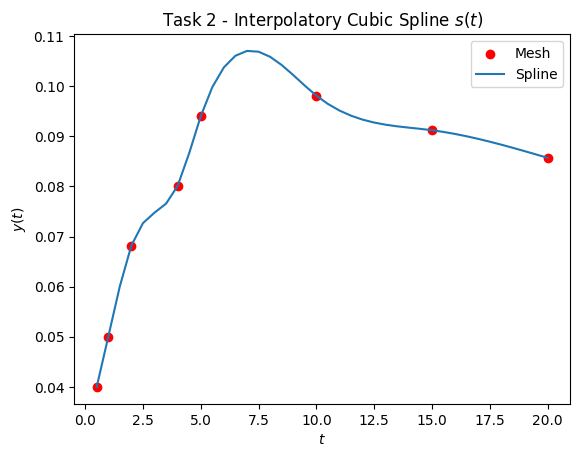

"\nplt.scatter(x_mesh, f_mesh, color='red', label='Mesh')\nplt.plot(t_vals, D_t, label='Spline')\nplt.xlabel('t')\nplt.ylabel('y(t)')\nplt.title('$D_t$')\nplt.legend()\nplt.show()\n\nplt.scatter(x_mesh, f_mesh, color='red', label='Mesh')\nplt.plot(t_vals, f_t, label='Spline')\nplt.xlabel('t')\nplt.ylabel('y(t)')\nplt.title('$f_t$')\nplt.legend()\nplt.show()\n"

In [9]:
def evaluate_spline_with_derivative(x_mesh, x_vals, gamma_vec, gamma_tilde_vec, s_dprime_vec, h_vec):
    # Alternate spline evaluation for Task 2 that also returns the derivative
    interp = []
    interp_derivative = []
    n_intervals = len(x_mesh) - 1

    for x in x_vals:
        for i in range(n_intervals):
            a_i, b_i = x_mesh[i], x_mesh[i+1]
            if a_i <= x <= b_i:

                # Compute spline value
                interpolated_value = (
                    (s_dprime_vec[i] * (b_i - x)**3) / (6 * h_vec[i+1]) + (s_dprime_vec[i+1] * (x - a_i)**3) / (6 * h_vec[i+1]) + gamma_vec[i] * (x - a_i) + gamma_tilde_vec[i])
                interp.append(interpolated_value)

                # Compute derivative
                interpolated_derivative = (
                    - (s_dprime_vec[i] * (x - b_i)**2) / (2 * h_vec[i+1]) + (s_dprime_vec[i+1] * (x - a_i)**2) / (2 * h_vec[i+1]) + gamma_vec[i])
                interp_derivative.append(interpolated_derivative)
                break  # exit the loop once a match is found to avoid redundancy

    return np.array(interp), np.array(interp_derivative)


x_mesh = np.array([0.5, 1.0, 2.0, 4.0, 5.0, 10.0, 15.0, 20.0])
f_mesh = np.array([0.04, 0.05, 0.0682, 0.0801, 0.0940, 0.0981, 0.0912, 0.0857])

s_dprime_0 = 0   # natural boundary conditions
s_dprime_n = 0

h_vec = np.diff(x_mesh)   # compute step sizes
h_vec = np.insert(h_vec, 0, np.nan)   # maintain alignment

h_sum = h_vec[1:-1] + h_vec[2:]   # compute h_i + h_{i+1}
mu_vec = h_vec[1:-1] / h_sum   # compute subdiagonal
lambda_vec = h_vec[2:] / h_sum   # compute superdiagonal

df_right = (f_mesh[2:] - f_mesh[1:-1]) / h_vec[2:]  # right divided difference
df_left = (f_mesh[1:-1] - f_mesh[:-2]) / h_vec[1:-1]  # left divided difference
d_vec = (6 / h_sum) * (df_right - df_left)   # compute right hand side vector

d_vec[0] -= mu_vec[0] * s_dprime_0
d_vec[-1] -= lambda_vec[-1] * s_dprime_n

s_dprime_vec = tridiagonal_system(2, mu_vec[1:], lambda_vec[:-1], d_vec)   # solve tridiagonal system
s_dprime_vec = np.insert(s_dprime_vec, 0, s_dprime_0)   # add back in boundary conditions
s_dprime_vec = np.append(s_dprime_vec, s_dprime_n)

gamma_tilde_vec = f_mesh[:-1] - (s_dprime_vec[:-1] * h_vec[1:] ** 2) / 6   # compute last two parameters
gamma_vec = (f_mesh[1:] - f_mesh[:-1]) / h_vec[1:] - (h_vec[1:] / 6) * (s_dprime_vec[1:] - s_dprime_vec[:-1])

# Evaluate spline
t_vals = np.linspace(0.5, 20, 40)
interp, interp_derivative = evaluate_spline_with_derivative(x_mesh, t_vals, gamma_vec, gamma_tilde_vec, s_dprime_vec, h_vec)
print("y(t): ", *interp)

# Compute D(t)
temp = (-1 * t_vals) * interp
D_t = np.exp(temp)
print("D(t): ", *D_t)

# Compute f(t)
f_t = interp + t_vals * interp_derivative
print("f(t): ", *f_t)


plt.scatter(x_mesh, f_mesh, color='red', label='Mesh')
plt.plot(t_vals, interp, label='Spline')
plt.xlabel('$t$')
plt.ylabel('$y(t)$')
plt.title('Task 2 - Interpolatory Cubic Spline $s(t)$')
plt.legend()
plt.show()

"""
plt.scatter(x_mesh, f_mesh, color='red', label='Mesh')
plt.plot(t_vals, D_t, label='Spline')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.title('$D_t$')
plt.legend()
plt.show()

plt.scatter(x_mesh, f_mesh, color='red', label='Mesh')
plt.plot(t_vals, f_t, label='Spline')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.title('$f_t$')
plt.legend()
plt.show()
"""
